# Notebook 13 – Model Evaluation: Regression


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description"]).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,AbsQuantity,Month,IsInternational
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,6,12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,8,12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0


## Setting Up a Regression Task

Every model in Notebooks 5, 7, 8, 9, and 10 was a **classifier** —
predicting a category (`IsCancelled`, `IsInternational`). This notebook
switches to **regression** — predicting a continuous number — in order to
demonstrate the metrics used to evaluate that kind of model.

**Our example:** predicting `AbsQuantity` (how many units were ordered)
from `UnitPrice`, `Month`, `IsInternational`, and `IsCancelled`. This is
a deliberately noisy, realistic regression task: order quantity is only
loosely related to these features, and — importantly for this notebook —
it contains some extreme outliers (a handful of wholesale-sized orders in
the thousands of units), which will matter a lot once MAE and RMSE are
compared.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

feature_cols = ["UnitPrice", "Month", "IsInternational", "IsCancelled"]
X = df[feature_cols]
y = df["AbsQuantity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

residuals = y_test - y_pred

print("Sample of actual vs. predicted values:")
comparison_preview = pd.DataFrame({"Actual": y_test.values[:10], "Predicted": np.round(y_pred[:10], 2)})
print(comparison_preview)
print("\nMax actual value in the test set (an example outlier):", y_test.max())

Sample of actual vs. predicted values:
   Actual  Predicted
0       6      10.09
1       1      10.04
2       3      10.32
3       1      10.37
4      20      10.00
5      10      10.08
6       1      10.04
7       2      10.01
8       4      10.07
9      10      10.31

Max actual value in the test set (an example outlier): 74215


## MAE — Mean Absolute Error

**What it measures:** the average size of the model's errors, ignoring
whether each prediction was too high or too low. It takes the absolute
value of every residual (`actual - predicted`), then averages them. The
result is in the *same units* as the target itself (here, "units
ordered"), which makes it very easy to explain: "on average, the model's
prediction is off by about X units."

**When to use it:** when every error should be weighted equally
regardless of size, and when the dataset has significant outliers that
shouldn't be allowed to dominate the evaluation (e.g. this dataset's rare,
enormous wholesale orders).

**Advantages:**
* Easy to interpret — it's in the original units of the target.
* Robust to outliers — one enormous error contributes only its own
  absolute value, not something inflated further.

**Limitations:**
* Treats all error sizes proportionally, so it doesn't specifically
  penalize a model for making a few very large mistakes — which can
  matter if large errors are especially costly in a given application.
* Its flat, non-smooth shape (an absolute value) makes it slightly less
  mathematically convenient to optimize directly than a squared-error
  metric like MSE.

In [3]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f} units")
print(f"(On average, the model's quantity prediction is off by about {mae:.1f} units.)")

MAE: 12.26 units
(On average, the model's quantity prediction is off by about 12.3 units.)


## MSE — Mean Squared Error

**What it measures:** the average of the *squared* residuals. Squaring
each error before averaging does two things: it makes every error
positive (so overestimates and underestimates don't cancel out), and it
disproportionately punishes *large* errors, since squaring a big number
makes it much bigger, while squaring a small number barely changes it.
The result is no longer in the original units — it's in "units
squared" — which makes MSE harder to interpret on its own (this is
exactly why RMSE, next, usually gets reported instead).

**When to use it:** when large errors are considered especially bad and
should be penalized more than proportionally — for example, if a
wildly wrong prediction is far more costly to the business than several
small mistakes.

**Advantages:**
* Mathematically convenient — smooth and differentiable everywhere,
  which is exactly why it's the standard loss function used to *train*
  many regression models (including Linear Regression's own fitting
  process) in the first place.
* Naturally emphasizes and surfaces large errors, which can be a useful
  signal that something is wrong with specific predictions.

**Limitations:**
* Hard to interpret directly, since its units are the square of the
  target's units ("units² ordered" doesn't mean much intuitively).
* Highly sensitive to outliers — a single very large error can dominate
  the entire metric, which is a strength or a weakness depending on
  whether that's actually the behavior wanted.

In [4]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:,.2f} (units-squared)")
print("Notice how much larger this number is than MAE, purely due to squaring outlier errors.")

MSE: 54,836.42 (units-squared)
Notice how much larger this number is than MAE, purely due to squaring outlier errors.


## RMSE — Root Mean Squared Error

**What it measures:** simply the square root of MSE. Taking the square
root brings the metric back into the original units of the target (here,
"units ordered" again), which restores interpretability, while *still*
keeping MSE's characteristic of penalizing large errors more heavily than
small ones. RMSE is usually reported instead of raw MSE for exactly this
reason: same underlying behavior, but interpretable again.

**When to use it:** the most common go-to metric for regression when
large errors genuinely matter more than small ones, and an
interpretable, same-units number is still wanted (most real-world
applications land here).

**Advantages:**
* Same interpretable units as the target, like MAE.
* Retains MSE's sensitivity to large errors, useful whenever big misses
  are disproportionately costly.

**Limitations:**
* Still sensitive to outliers — a few extreme residuals can inflate it
  well above what MAE would report for the same predictions, which can
  make a model look worse than it "typically" performs.
* Because it's always ≥ MAE (and the two only become equal when every
  error is exactly the same size), comparing MAE and RMSE side-by-side is
  itself informative — a big gap between them signals that a few large
  errors are present.

In [5]:
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f} units")
print(f"MAE:  {mae:.2f} units")
print(f"\nRMSE is {rmse / mae:.2f}x larger than MAE here — a clear sign that a handful of large")
print("outlier errors are pulling RMSE up much more than they pull MAE up.")

RMSE: 234.17 units
MAE:  12.26 units

RMSE is 19.10x larger than MAE here — a clear sign that a handful of large
outlier errors are pulling RMSE up much more than they pull MAE up.


## R² Score (Coefficient of Determination)

**What it measures:** the proportion of the variance in the target that
the model explains, relative to a naive baseline that always predicts the
target's mean. It's calculated as `1 - (SS_residual / SS_total)`, where
`SS_residual` is the sum of squared errors of the model, and `SS_total`
is the sum of squared errors of that naive "always predict the mean"
baseline. An R² of 1.0 means the model explains all the variance
(perfect predictions); an R² of 0.0 means it does no better than always
guessing the mean; a negative R² means it does *worse* than that trivial
baseline.

**When to use it:** when a single, scale-free summary of "how much better
than a naive guess is this model" is wanted — especially useful for
comparing models across different targets or datasets, since (unlike MAE,
MSE, RMSE) R² isn't tied to the original units at all.

**Advantages:**
* Scale-free and easy to compare across different problems.
* Intuitive baseline built in — 0 always means "no better than guessing
  the average," which gives an immediate sense of scale.

**Limitations:**
* Can be misleadingly inflated by simply adding more features to the
  model, even features that are pure noise (fixed by Adjusted R², next).
* A high R² doesn't guarantee the model is *good* in an absolute sense —
  it's all relative to how much the target varies in the first place.
* Doesn't say anything about *which* predictions are off, or by how
  much in real terms (residual analysis, below, fills that gap).

In [6]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"R\u00b2 Score: {r2:.4f}")
print(f"The model explains about {r2:.1%} of the variance in AbsQuantity",
      "(the rest is noise, or driven by features not included here)." if r2 > 0 else
      "-- meaning it does WORSE than simply predicting the average every time.")

R² Score: 0.0004
The model explains about 0.0% of the variance in AbsQuantity (the rest is noise, or driven by features not included here).


## Adjusted R²

**What it measures:** the same idea as R², but with a built-in penalty for
the number of features used, specifically correcting for the fact that
plain R² can only go up (or stay the same) every time a new feature is
added, *even if that feature is completely useless* — simply because a
model with more parameters can always fit the training data at least as
well by chance. The formula is:

`Adjusted R² = 1 - [(1 - R²) * (n - 1) / (n - p - 1)]`

where `n` is the number of observations and `p` is the number of
features. As `p` grows, the correction term grows too, dragging Adjusted
R² down unless the new feature actually earns its keep by improving R²
enough to offset the penalty.

**When to use it:** whenever comparing models that use *different numbers
of features* — which is most model comparisons in practice. Plain R² is
not a fair comparison in that situation; Adjusted R² is.

**Advantages:**
* Discourages simply throwing more features at a model to inflate R²
  artificially.
* Makes model comparisons across different feature sets fair.

**Limitations:**
* Still inherits R²'s other limitations (relative-to-variance, not
  absolute error size).
* Can occasionally be harder to interpret intuitively than plain R²,
  since it's no longer a pure "percentage of variance explained" once
  the penalty is applied.

**Demonstration:** below, a completely random, meaningless feature is
added to the model. Plain R² ticks up slightly anyway (proving it can be
gamed by noise); Adjusted R² is designed specifically to resist that.

In [7]:
def adjusted_r2(r2_value, n_obs, n_features):
    return 1 - (1 - r2_value) * (n_obs - 1) / (n_obs - n_features - 1)

n_obs = len(y_test)
n_features_original = len(feature_cols)
adj_r2_original = adjusted_r2(r2, n_obs, n_features_original)

# Add a completely random, meaningless feature and refit
rng = np.random.default_rng(42)
X_train_noisy = X_train.copy()
X_test_noisy = X_test.copy()
X_train_noisy["RandomNoise"] = rng.normal(size=len(X_train_noisy))
X_test_noisy["RandomNoise"] = rng.normal(size=len(X_test_noisy))

reg_model_noisy = LinearRegression()
reg_model_noisy.fit(X_train_noisy, y_train)
y_pred_noisy = reg_model_noisy.predict(X_test_noisy)

r2_noisy = r2_score(y_test, y_pred_noisy)
adj_r2_noisy = adjusted_r2(r2_noisy, n_obs, n_features_original + 1)

print(f"{'Model':35s} {'R\u00b2':>10s} {'Adjusted R\u00b2':>16s}")
print(f"{'Original (4 real features)':35s} {r2:10.5f} {adj_r2_original:16.5f}")
print(f"{'+ 1 random noise feature':35s} {r2_noisy:10.5f} {adj_r2_noisy:16.5f}")

Model                                       R²      Adjusted R²
Original (4 real features)             0.00045          0.00041
+ 1 random noise feature               0.00047          0.00042


Plain R² either stays flat or nudges upward with the meaningless extra
feature (it mathematically cannot go down), while Adjusted R² moves down
or fails to improve nearly as much, correctly reflecting that nothing
useful was actually gained.

## Residual Analysis

**What it is:** rather than boiling performance down to a single number,
residual analysis means directly plotting and inspecting the residuals
(`actual - predicted`) to look for patterns a summary metric can hide. A
well-fitting linear model's residuals should look like unstructured
random noise, centered around zero, with roughly constant spread across
the whole range of predictions (a property called **homoscedasticity**).
If a *pattern* shows up in the residuals instead, it's evidence the model
is systematically missing something.

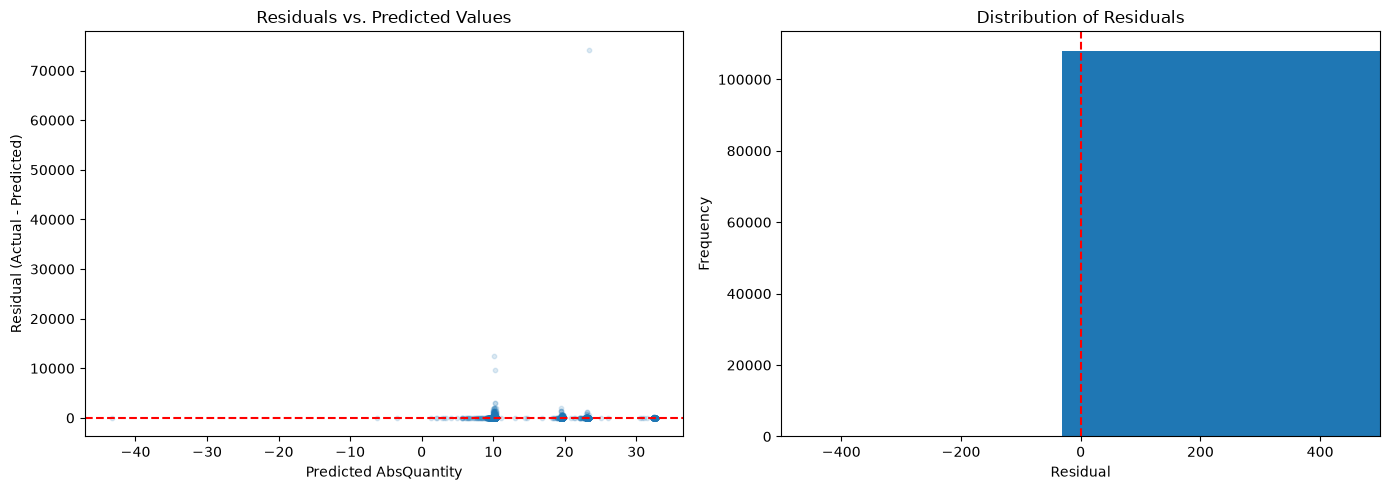

Residual mean (should be close to 0 for an unbiased linear model): 0.2358
Residual std deviation: 234.17


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs. Predicted values
axes[0].scatter(y_pred, residuals, alpha=0.15, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted AbsQuantity")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs. Predicted Values")

# Distribution of residuals
axes[1].hist(residuals, bins=80)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlim(-500, 500)  # zoomed in, since a few extreme outlier residuals would otherwise dominate the view

plt.tight_layout()
plt.show()

print("Residual mean (should be close to 0 for an unbiased linear model):", round(residuals.mean(), 4))
print("Residual std deviation:", round(residuals.std(), 2))